# Summarization
- **ROUGE score:** similarity between generated a summary and reference summaries
    - Looks at n-grams and overlapping
    - `predictions`: LLM outputs
    - `references`: human-provided summaries

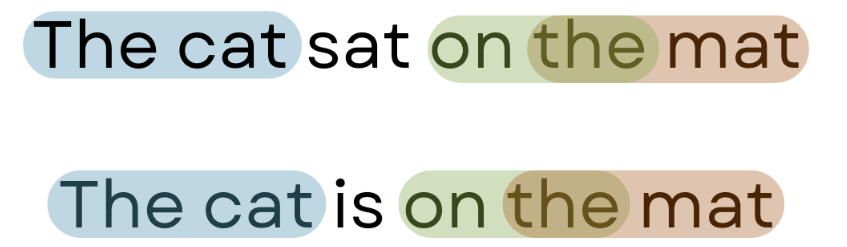

**ROUGE scores:**
- `rouge1`: unigram overlap
- `rouge2`: bigram overlap
- `rougeL`: long overlapping subsequences

In [4]:
import evaluate

rouge = evaluate.load('rouge')
predictions = ['''as we learn more about the frequency and size distribution of exoplanets, we are discovering that terrestrial planets are exceedingly common.''']

references = ['''The more we learn about the frequency and size distribution of exoplanets, the more confident we are that they are exceedingly common.''']

In [14]:
results = rouge.compute(predictions=predictions, references=references)

print([f'{score}: {result:.4f}' for score, result in results.items()])

['rouge1: 0.7907', 'rouge2: 0.5366', 'rougeL: 0.7442', 'rougeLsum: 0.7442']


- Scores between 0-1: higher score indicates higher similarity

# Translation
- **METEOR**: more linguistic features like word variations, similar meanings, and word order
- **BLEU score**

In [16]:
meteor = evaluate.load('meteor')
bleu = evaluate.load('bleu')

predictions = ['''He thought it right and necessary to become a knight-errant, roaming the world in armor, seeking adventures and practicing the deeds he had read about in chivalric tales.''']

reference = ['''He believed it was proper and essential to transform into a knight-errant, traveling the world in armor, pursuing adventures, and enacting the heroic deeds he had encountered in tales of chivalry.''']

results_meteor = meteor.compute(predictions=predictions, references=reference)
results_bleu = bleu.compute(predictions=predictions, references=reference)
print("METEOR: ", results_meteor)
print("BLEU: ", results_bleu)

[nltk_data] Downloading package wordnet to /home/phomint/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/phomint/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/phomint/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


METEOR:  {'meteor': np.float64(0.5350702240481536)}
BLEU:  {'bleu': 0.19088841781992524, 'precisions': [0.6774193548387096, 0.26666666666666666, 0.1724137931034483, 0.07142857142857142], 'brevity_penalty': 0.8789456120040121, 'length_ratio': 0.8857142857142857, 'translation_length': 31, 'reference_length': 35}


- `0-1` score: higher is better

## Question-answering
- **Extractive QA**:
    - **EM (Exact Match)**: 1 if an LLM's output exactly matches its reference answer,
    - **F1 (F-score)**: Normally used in conjunction with EM


In [17]:
### Exact Match (EM) example
em_metric = evaluate.load('exact_match')
predictions = ['The cat sat on the mat', 'Theaters are great', 'Like comparing oranges and apples']
references = ['The cat sat on the mat?', 'Theaters are great', 'Like comparing apples and oranges']

results = em_metric.compute(predictions=predictions, references=references)
print(results)

{'exact_match': np.float64(0.3333333333333333)}


- **Generative QA**:
    - **BLEU score / ROUGE score**